# Clasificación de audio real con Transformada Wavelet Continua (CWT) + CNN

**Maestría en Ciencia de Datos — UANL** · Procesamiento y clasificación de datos

Dataset real: `activeloop/spoken_mnist` (dígitos hablados 0–9, mismo dataset usado en Clase 8).

Al final del notebook se imprime/guarda un resumen (`resumen_resultados.json`) con las métricas y rutas de las figuras — cópialo y pásaselo a Claude para completar el reporte en Markdown con datos reales.

In [3]:
# Dependencias (Colab ya trae tensorflow/sklearn/matplotlib; solo faltan estas dos)
!python -m pip install PyWavelets



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pywt
import deeplake
import librosa
from scipy.ndimage import zoom
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
import json

np.random.seed(42)
tf.random.set_seed(42)

C:\Users\Oscar Ferreira\AppData\Local\Programs\Python\Python311\Lib\site-packages\humbug\report.py:47: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # type: ignore
C:\Users\Oscar Ferreira\AppData\Local\Programs\Python\Python311\Lib\site-packages\deeplake\util\check_latest_version.py:32: UserWarning: A newer version of deeplake (4.7.0) is available. It's recommended that you update to the latest version using `pip install -U deeplake`.
  warnings.warn(


## 1. Cargar dataset real

In [2]:
ds = deeplake.load('hub://activeloop/spoken_mnist')
print(ds)
print('Tamaño total:', len(ds))

|

Opening dataset in read-only mode as you don't have write permissions.


/

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/spoken_mnist



\

hub://activeloop/spoken_mnist loaded successfully.

Dataset(path='hub://activeloop/spoken_mnist', read_only=True, tensors=['spectrograms', 'labels', 'audio', 'speakers'])
Tamaño total: 3000


In [3]:
# Muestra de exploración: revisa cómo vienen el audio y el label del primer registro
# (ajusta esta celda si la estructura difiere de lo esperado)
sample0 = ds[0]
print('label:', sample0['labels'].data())
audio0 = sample0['audio'].data()['value']
print('audio shape:', audio0.shape, 'dtype:', audio0.dtype)

label: {'value': array([0], dtype=uint32), 'text': ['0']}
audio shape: (2384, 1) dtype: float64


## 2. Submuestrear el dataset

Se toman `N_POR_CLASE` ejemplos por dígito (0–9) para mantener el tiempo de entrenamiento razonable en CPU/GPU de Colab. Sube este número si quieres más datos (y tienes GPU).

In [4]:
N_POR_CLASE = 150   # súbelo (p.ej. 300) si tienes GPU y quieres más robustez
SR_TARGET = 8000     # frecuencia de muestreo objetivo (remuestrea si el audio original es distinto)
DUR_TARGET = 0.6     # segundos -> longitud fija por muestra (pad/trim)
LEN_TARGET = int(SR_TARGET * DUR_TARGET)

conteo_por_clase = {i: 0 for i in range(10)}
audios, labels = [], []

for i in range(len(ds)):
    label = int(ds[i]['labels'].data()['value'])
    if conteo_por_clase[label] >= N_POR_CLASE:
        continue
    audio_info = ds[i]['audio'].data()
    y = np.asarray(audio_info['value']).astype(np.float32).flatten()
    sr_orig = audio_info.get('sample_info', {}).get('sample_rate', SR_TARGET)
    if sr_orig and sr_orig != SR_TARGET:
        y = librosa.resample(y, orig_sr=sr_orig, target_sr=SR_TARGET)
    # normalizar amplitud
    if np.abs(y).max() > 0:
        y = y / np.abs(y).max()
    # pad / truncar a longitud fija
    if len(y) < LEN_TARGET:
        y = np.pad(y, (0, LEN_TARGET - len(y)))
    else:
        y = y[:LEN_TARGET]
    audios.append(y)
    labels.append(label)
    conteo_por_clase[label] += 1
    if all(c >= N_POR_CLASE for c in conteo_por_clase.values()):
        break

X_audio = np.array(audios)
y_labels = np.array(labels)
print('Dataset submuestreado:', X_audio.shape, '| clases:', conteo_por_clase)

C:\Users\Oscar Ferreira\AppData\Local\Temp\ipykernel_2628\2476547138.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(ds[i]['labels'].data()['value'])
C:\Users\Oscar Ferreira\AppData\Local\Programs\Python\Python311\Lib\site-packages\deeplake\core\dataset\dataset.py:642: UserWarning: Indexing by integer in a for loop, like `for i in range(len(ds)): ... ds[i]` can be quite slow. Use `for i, sample in enumerate(ds)` instead.
  warnings.warn(


Dataset submuestreado: (1500, 4800) | clases: {0: 150, 1: 150, 2: 150, 3: 150, 4: 150, 5: 150, 6: 150, 7: 150, 8: 150, 9: 150}


## 3. Extracción de features — CWT (ondícula de Morlet)

In [5]:
WAVELET = 'cmor1.5-1.0'
N_SCALES = 64
IMG_SIZE = (64, 64)
FREQ_MIN, FREQ_MAX = 50, SR_TARGET // 2

central_freq = pywt.central_frequency(WAVELET)
scale_min = central_freq * SR_TARGET / FREQ_MAX
scale_max = central_freq * SR_TARGET / FREQ_MIN
SCALES = np.geomspace(scale_min, scale_max, N_SCALES)

def signal_to_scalogram(sig):
    coef, _ = pywt.cwt(sig, SCALES, WAVELET, sampling_period=1 / SR_TARGET)
    mag = np.log1p(np.abs(coef))
    zf = (IMG_SIZE[0] / mag.shape[0], IMG_SIZE[1] / mag.shape[1])
    img = zoom(mag, zf, order=1)
    img = (img - img.min()) / (img.max() - img.min() + 1e-9)
    return img.astype(np.float32)

X_scalograms = np.zeros((len(X_audio), *IMG_SIZE, 1), dtype=np.float32)
for i, sig in enumerate(X_audio):
    X_scalograms[i, :, :, 0] = signal_to_scalogram(sig)
    if i % 200 == 0:
        print(f'{i}/{len(X_audio)} scalogramas listos')

print('Shape final:', X_scalograms.shape)

0/1500 scalogramas listos
200/1500 scalogramas listos
400/1500 scalogramas listos
600/1500 scalogramas listos
800/1500 scalogramas listos
1000/1500 scalogramas listos
1200/1500 scalogramas listos
1400/1500 scalogramas listos
Shape final: (1500, 64, 64, 1)


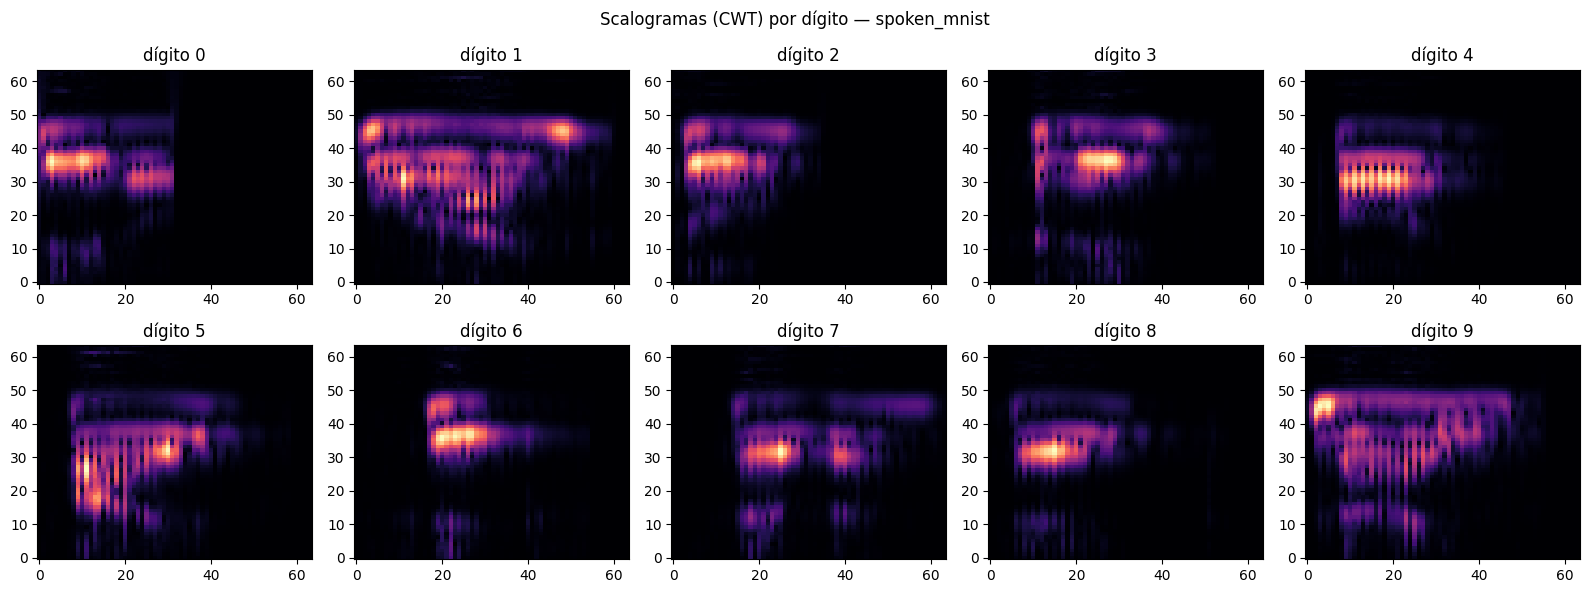

In [6]:
# Visualizar un scalograma por dígito (0-9)
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for digito in range(10):
    idx = np.where(y_labels == digito)[0][0]
    ax = axes[digito // 5, digito % 5]
    ax.imshow(X_scalograms[idx, :, :, 0], aspect='auto', origin='lower', cmap='magma')
    ax.set_title(f'dígito {digito}')
plt.suptitle('Scalogramas (CWT) por dígito — spoken_mnist')
plt.tight_layout()
plt.savefig('scalogramas_por_digito.png', dpi=130)
plt.show()

## 4. Entrenar CNN

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

X_train, X_test, y_train, y_test = train_test_split(
    X_scalograms, y_labels, test_size=0.25, random_state=42, stratify=y_labels
)
model = keras.Sequential([
    keras.layers.Input(shape=X_scalograms.shape[1:]),
    keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(32, 3, activation='relu', padding='same'),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, activation='relu', padding='same'),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=20,
    restore_best_weights=True,  # al terminar, el modelo queda con los pesos del mejor epoch
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=300,           # sigue siendo el techo, pero ya no lo vas a alcanzar
    batch_size=32,
    verbose=2,
    callbacks=[early_stop],
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)                    │ (None, 64, 64, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 32, 32, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 64)                  │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 28,106 (109.79 KB)

 Trainable params: 28,106 (109.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
29/29 - 4s - 138ms/step - accuracy: 0.0889 - loss: 2.2957 - val_accuracy: 0.0978 - val_loss: 2.2893
Epoch 2/300
29/29 - 1s - 30ms/step - accuracy: 0.1056 - loss: 2.2742 - val_accuracy: 0.0978 - val_loss: 2.2614
Epoch 3/300
29/29 - 1s - 33ms/step - accuracy: 0.1389 - loss: 2.2321 - val_accuracy: 0.2267 - val_loss: 2.1921
Epoch 4/300
29/29 - 1s - 29ms/step - accuracy: 0.1667 - loss: 2.1700 - val_accuracy: 0.2089 - val_loss: 2.0814
Epoch 5/300
29/29 - 1s - 27ms/step - accuracy: 0.1722 - loss: 2.1032 - val_accuracy: 0.2800 - val_loss: 2.0046
Epoch 6/300
29/29 - 1s - 27ms/step - accuracy: 0.2278 - loss: 2.0429 - val_accuracy: 0.2578 - val_loss: 1.9701
Epoch 7/300
29/29 - 1s - 28ms/step - accuracy: 0.2378 - loss: 2.0377 - val_accuracy: 0.2533 - val_loss: 1.9417
Epoch 8/300
29/29 - 1s - 28ms/step - accuracy: 0.2411 - loss: 1.9868 - val_accuracy: 0.2667 - val_loss: 1.9245
Epoch 9/300
29/29 - 1s - 28ms/step - accuracy: 0.2478 - loss: 2.0106 - val_accuracy: 0.3289 - val_loss: 1.8863


## 5. Evaluación

Accuracy en test: 0.8933
              precision    recall  f1-score   support

           0      0.974     1.000     0.987        37
           1      0.914     0.865     0.889        37
           2      0.841     0.974     0.902        38
           3      0.882     0.789     0.833        38
           4      0.881     0.974     0.925        38
           5      0.882     0.811     0.845        37
           6      0.927     1.000     0.962        38
           7      0.947     0.973     0.960        37
           8      0.818     0.730     0.771        37
           9      0.861     0.816     0.838        38

    accuracy                          0.893       375
   macro avg      0.893     0.893     0.891       375
weighted avg      0.893     0.893     0.891       375



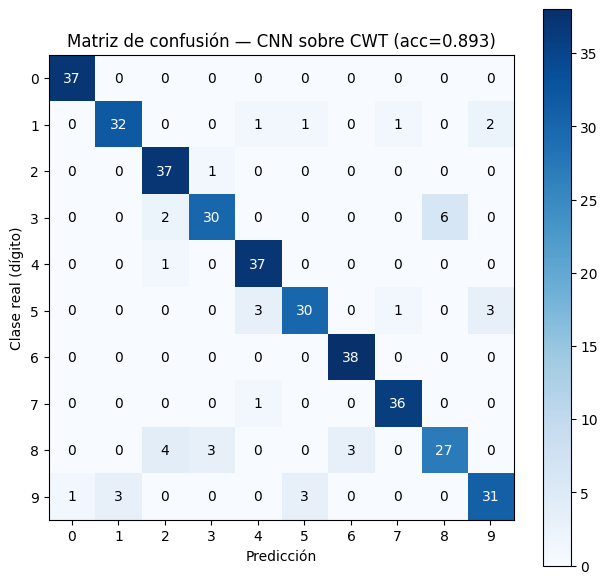

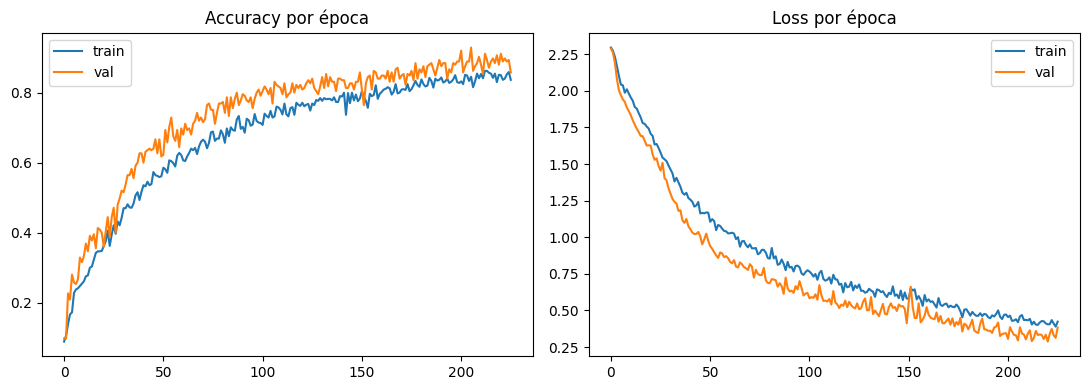

In [11]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Accuracy en test: {test_acc:.4f}')

y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
reporte_txt = classification_report(y_test, y_pred, digits=3)
print(reporte_txt)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6.5, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel('Predicción'); ax.set_ylabel('Clase real (dígito)')
ax.set_title(f'Matriz de confusión — CNN sobre CWT (acc={test_acc:.3f})')
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=130)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy por época'); axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss por época'); axes[1].legend()
plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=130)
plt.show()

## 6. Guardar resumen para el reporte

Corre esta celda al final, copia el JSON impreso (o el archivo `resumen_resultados.json`) y pásaselo a Claude junto con las 3 imágenes generadas (`scalogramas_por_digito.png`, `matriz_confusion.png`, `curvas_entrenamiento.png`) para completar el reporte en Markdown con resultados reales.

In [12]:
resumen = {
    'dataset': 'activeloop/spoken_mnist',
    'n_por_clase': N_POR_CLASE,
    'n_total': int(len(X_audio)),
    'sr': SR_TARGET,
    'duracion_s': DUR_TARGET,
    'wavelet': WAVELET,
    'n_scales': N_SCALES,
    'img_size': IMG_SIZE,
    'test_accuracy': float(test_acc),
    'confusion_matrix': cm.tolist(),
    'classification_report': reporte_txt,
}
with open('resumen_resultados.json', 'w') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print(json.dumps(resumen, indent=2, ensure_ascii=False))

{
  "dataset": "activeloop/spoken_mnist",
  "n_por_clase": 150,
  "n_total": 1500,
  "sr": 8000,
  "duracion_s": 0.6,
  "wavelet": "cmor1.5-1.0",
  "n_scales": 64,
  "img_size": [
    64,
    64
  ],
  "test_accuracy": 0.8933333158493042,
  "confusion_matrix": [
    [
      37,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      32,
      0,
      0,
      1,
      1,
      0,
      1,
      0,
      2
    ],
    [
      0,
      0,
      37,
      1,
      0,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      2,
      30,
      0,
      0,
      0,
      0,
      6,
      0
    ],
    [
      0,
      0,
      1,
      0,
      37,
      0,
      0,
      0,
      0,
      0
    ],
    [
      0,
      0,
      0,
      0,
      3,
      30,
      0,
      1,
      0,
      3
    ],
    [
      0,
      0,
      0,
      0,
      0,
      0,
      38,
      0,
      0,
      0
    ],
    [
      0,
 